In [1]:
!pip install Sastrawi
!pip install emoji
!pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 19.1 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np
import json
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

import emoji

In [3]:
from google.colab import drive

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Dataset_codingcamp_loker/data_untuk_modeling.csv'

Mounted at /content/drive


In [2]:
file_path = "data_untuk_modeling.csv"

#### Preprocessing Text

In [40]:
df = pd.read_csv(file_path)
df.columns.tolist()

['Unnamed: 0',
 'Judul',
 'Industri',
 'Tipe',
 'Kategori',
 'Kota',
 'Provinsi',
 'Negara',
 'Gaji_Min',
 'Gaji_Max',
 'Skills',
 'Pengalaman_Bulan',
 'Pendidikan',
 'Deskripsi']

In [5]:
# mengecek kolom kosong
df.isnull().sum()

,0
Unnamed: 0,0
Judul,0
Industri,0
Tipe,0
Kategori,0
Kota,0
Provinsi,0
Negara,0
Gaji_Min,0
Gaji_Max,0


In [ ]:
df.head(3)

,Unnamed: 0,Judul,Industri,Tipe,Kategori,Kota,Provinsi,Negara,Gaji_Min,Gaji_Max,Skills,Pengalaman_Bulan,Pendidikan,Deskripsi
0,0,IT Business Analyst,Information Technology and Services,FULL_TIME,System Analyst,Jakarta Timur,DKI Jakarta,ID,Tidak ada,Tidak ada,"SQL, Business Analysis, Relational Databases, ...",36.0,bachelor degree,Job description \n \n Evaluating and documenti...
1,1,IT System Analyst,Information Technology and Services,FULL_TIME,System Analyst,Surabaya,Jawa Timur,ID,7000000.0,9000000.0,"Requirements Analysis, SQL, Business Analysis,...",12.0,bachelor degree,General Qualification : \n \n Man (23 - 35 yea...
2,2,IT Business Analyst - Insurance exp,Information Technology and Services,CONTRACTOR,Business Analyst,Jakarta Selatan,DKI Jakarta,ID,13000000.0,14500000.0,"SDLC, Life Insurance, Teamwork, Business Proce...",36.0,bachelor degree,Skill And Experience : \n - Understand the Bas...


In [41]:
# Sisi Lowongan (Job)
df['job_core'] = (
    # "judul: " + df['Judul'].fillna('') + " " +
    "skills: " + df['Skills'].fillna('')
)
df['job_context'] = (
    "industri: " + df['Industri'].fillna('') + " " +
    "kategori: " + df["Kategori"].fillna('') + " " +
    "deskripsi: " + df['Deskripsi'].fillna('') + " " +
    "lokasi: " + df['Kota'].fillna('') + " " + df['Provinsi'].fillna('') + " " +
    "pendidikan: " + df['Pendidikan'].fillna('') 
)

print("Contoh teks job_core:")
print(df['job_core'].iloc[0])

# Sisi Pseudo-CV
df['cv_core'] = (
    # "judul: " + df['Judul'].fillna('') + " " + 
    "skills: " + df['Skills'].fillna('')
)
df['cv_context'] = (
    "industri: " + df['Industri'].fillna('') + " " +
    "kategori: " + df["Kategori"].fillna('') + " " +
    "pendidikan: " + df['Pendidikan'].fillna('')
)
print("\nContoh teks cv_core:")
print(df['cv_core'].iloc[0])


Contoh teks job_core:
skills: SQL, Business Analysis, Relational Databases, System Analysis, Analytical Skills, SDLC

Contoh teks cv_core:
skills: SQL, Business Analysis, Relational Databases, System Analysis, Analytical Skills, SDLC


##### Cleaning

In [42]:

def basic_clean(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)                 # HTML
    text = re.sub(r'[^a-z0-9\s:/_\-\+\.]', ' ', text) # keep tanda penting
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# df['text_gabungan'] = df['text_gabungan'].apply(basic_clean)
# print(df['text_gabungan'][0])

df['job_core'] = df['job_core'].apply(basic_clean)
df['job_context'] = df['job_context'].apply(basic_clean)
df['cv_core'] = df['cv_core'].apply(basic_clean)
df['cv_context'] = df['cv_context'].apply(basic_clean)

##### Case Folding

In [43]:
def case_folding(text):
    text = text.lower()
    return text

# df["text_gabungan"] = df["text_gabungan"].apply(case_folding)
# print(df["text_gabungan"][1])
df['job_core'] = df['job_core'].apply(case_folding)
df['job_context'] = df['job_context'].apply(case_folding)
df['cv_core'] = df['cv_core'].apply(case_folding)
df['cv_context'] = df['cv_context'].apply(case_folding)

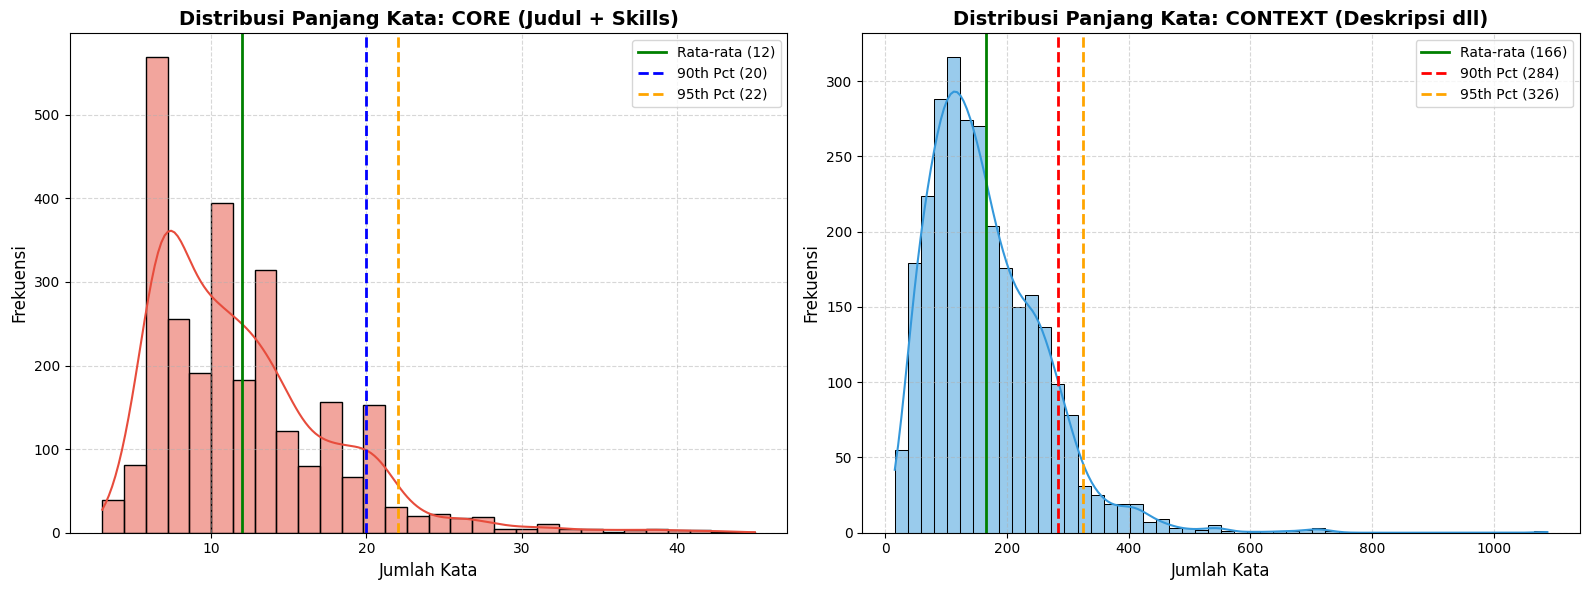

=== RINGKASAN STATISTIK UNTUK CORE ===
Rata-rata : 12 kata
90% data  : 20 kata
95% data  : 22 kata
Maksimum  : 45 kata

=== RINGKASAN STATISTIK UNTUK CONTEXT ===
Rata-rata : 166 kata
90% data  : 284 kata
95% data  : 326 kata
Maksimum  : 1088 kata


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Pastikan kolom job_core dan job_context sudah ada
# (Disesuaikan dengan cara kamu membentuk teksnya)
# df['job_core'] = "judul: " + df['Judul'].fillna('') + " skills: " + df['Skills'].fillna('')
# df['job_context'] = "deskripsi: " + df['Deskripsi'].fillna('') + " lokasi: " + df['Kota'].fillna('')

# 2. Menghitung jumlah kata untuk masing-masing bagian
df['seq_len_core'] = df['job_core'].apply(lambda x: len(str(x).split()))
df['seq_len_ctx'] = df['job_context'].apply(lambda x: len(str(x).split()))

# 3. Setup Kanvas untuk 2 Plot (1 baris, 2 kolom)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==========================================
# PLOT 1: DISTRIBUSI PANJANG CORE
# ==========================================
sns.histplot(df['seq_len_core'], bins=30, kde=True, color='#e74c3c', ax=axes[0])
core_mean = df['seq_len_core'].mean()
core_p90 = np.percentile(df['seq_len_core'], 90)
core_p95 = np.percentile(df['seq_len_core'], 95)

axes[0].axvline(core_mean, color='green', linestyle='-', linewidth=2, label=f'Rata-rata ({core_mean:.0f})')
axes[0].axvline(core_p90, color='blue', linestyle='--', linewidth=2, label=f'90th Pct ({core_p90:.0f})')
axes[0].axvline(core_p95, color='orange', linestyle='--', linewidth=2, label=f'95th Pct ({core_p95:.0f})')

axes[0].set_title('Distribusi Panjang Kata: CORE (Judul + Skills)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Jumlah Kata', fontsize=12)
axes[0].set_ylabel('Frekuensi', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# ==========================================
# PLOT 2: DISTRIBUSI PANJANG CONTEXT
# ==========================================
sns.histplot(df['seq_len_ctx'], bins=50, kde=True, color='#3498db', ax=axes[1])
ctx_mean = df['seq_len_ctx'].mean()
ctx_p90 = np.percentile(df['seq_len_ctx'], 90)
ctx_p95 = np.percentile(df['seq_len_ctx'], 95)

axes[1].axvline(ctx_mean, color='green', linestyle='-', linewidth=2, label=f'Rata-rata ({ctx_mean:.0f})')
axes[1].axvline(ctx_p90, color='red', linestyle='--', linewidth=2, label=f'90th Pct ({ctx_p90:.0f})')
axes[1].axvline(ctx_p95, color='orange', linestyle='--', linewidth=2, label=f'95th Pct ({ctx_p95:.0f})')

axes[1].set_title('Distribusi Panjang Kata: CONTEXT (Deskripsi dll)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Jumlah Kata', fontsize=12)
axes[1].set_ylabel('Frekuensi', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# PRINT RINGKASAN ANGKA
# ==========================================
print("=== RINGKASAN STATISTIK UNTUK CORE ===")
print(f"Rata-rata : {core_mean:.0f} kata")
print(f"90% data  : {core_p90:.0f} kata")
print(f"95% data  : {core_p95:.0f} kata")
print(f"Maksimum  : {df['seq_len_core'].max()} kata\n")

print("=== RINGKASAN STATISTIK UNTUK CONTEXT ===")
print(f"Rata-rata : {ctx_mean:.0f} kata")
print(f"90% data  : {ctx_p90:.0f} kata")
print(f"95% data  : {ctx_p95:.0f} kata")
print(f"Maksimum  : {df['seq_len_ctx'].max()} kata")

In [45]:
# normalization_dict = dict(zip(df_normalisasi['slang'], df_normalisasi['formal']))
# normalization_dict.pop('it')

# def normalization(text):
#     words = text.split()
#     words = [normalization_dict.get(word, word) for word in words]
#     return ' '.join(words)

# df['text_gabungan'] = df["text_gabungan"].apply(normalization)
# print(df['text_gabungan'][1])

##### Stopword Removal

In [ ]:
# tidak relevan untuk kasus INDO ENGLISH, karena banyak kata yang sudah baku dan tidak ada slang yang perlu dinormalisasi dan Stopword

#### Membangun Modeling dengan Pseudo-CV


#### Membangun Data Pseudo-CV

In [1]:
# from sentence_transformers import SentenceTransformer, InputExample
# from sentence_transformers.sentence_transformer import losses
# from torch.utils.data import DataLoader

# model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

In [ ]:
# train_examples = [
#     InputExample(texts=[df['pseudo_cv'], df['text_gabungan']])
#     # for pseudo_cv, job_full in pairs
#     for df['pseudo_cv'], df['text_gabungan'] in zip(df['pseudo_cv'], df['text_gabungan'])
# ]

# train_loader = DataLoader(train_examples, batch_size=16, shuffle=True)
# loss_fn = losses.MultipleNegativesRankingLoss(model)

# model.fit(
#     train_objectives=[(train_loader, loss_fn)],
#     epochs=1
# )

#### Inferens

In [ ]:
# cv_emb = model.encode(real_cv_text)
# job_embs = model.encode(job_list)

# scores = cosine_similarity([cv_emb], job_embs)

In [48]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, Dot, Flatten, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
# import Adam optimizer
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [49]:
cv_core = []
cv_ctx = []
job_core = []
job_ctx = []
labels = []

# Data Positif (Cocok = 1) -> pseudo_cv dipasangkan dengan job aslinya
for i in range(len(df)):
    cv_core.append(df['cv_core'].iloc[i])
    cv_ctx.append(df['cv_context'].iloc[i])
    job_core.append(df['job_core'].iloc[i])
    job_ctx.append(df['job_context'].iloc[i])
    labels.append(1)

# Data Negatif (Tidak Cocok = 0) -> pseudo_cv dipasangkan dengan job random
# Ini penting agar model LSTM tidak sekadar menebak "1" terus menerus
for i in range(len(df)):
    random_idx = np.random.choice([x for x in range(len(df)) if x != i])
    cv_core.append(df['cv_core'].iloc[i])
    cv_ctx.append(df['cv_context'].iloc[i])
    job_core.append(df['job_core'].iloc[random_idx])
    job_ctx.append(df['job_context'].iloc[random_idx])
    labels.append(0)

# Convert ke numpy array
labels = np.array(labels)

In [50]:
MAX_VOCAB = 30000
# masih perlu diteliti lebih lanjut
MAX_LEN_CORE = 22
MAX_LEN_CTX = 326

In [51]:
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
# Fit tokenizer ke semua teks (CV + Job)
tokenizer.fit_on_texts(cv_core + cv_ctx + job_core + job_ctx)

# Convert teks ke sequence angka dan lakukan padding
cv_core_seq = pad_sequences(tokenizer.texts_to_sequences(cv_core), maxlen=MAX_LEN_CORE, padding='post')
cv_ctx_seq = pad_sequences(tokenizer.texts_to_sequences(cv_ctx), maxlen=MAX_LEN_CTX, padding='post')
job_core_seq = pad_sequences(tokenizer.texts_to_sequences(job_core), maxlen=MAX_LEN_CORE, padding='post')
job_ctx_seq = pad_sequences(tokenizer.texts_to_sequences(job_ctx), maxlen=MAX_LEN_CTX, padding='post')

In [52]:
from sklearn.model_selection import train_test_split

(X_cv_core_train, X_cv_core_test, 
 X_cv_ctx_train, X_cv_ctx_test, 
 X_job_core_train, X_job_core_test, 
 X_job_ctx_train, X_job_ctx_test, 
 y_train, y_test) = train_test_split(
    cv_core_seq,
    cv_ctx_seq,
    job_core_seq,
    job_ctx_seq,
    labels,
    test_size=0.15,
    random_state=42
)

print(f"Total data Train (termasuk Validation nanti): {len(y_train)}")
print(f"Total data Test murni: {len(y_test)}")

Total data Train (termasuk Validation nanti): 4693
Total data Test murni: 829


In [53]:
# 3. MEMBANGUN ARSITEKTUR CUSTOM LAYER (Siamese BiLSTM)
embedding_dim = 64

In [54]:
# 1. Definisi Input
cv_core_in = Input(shape=(MAX_LEN_CORE,), name="cv_core_in")
cv_ctx_in = Input(shape=(MAX_LEN_CTX,), name="cv_ctx_in")

job_core_in = Input(shape=(MAX_LEN_CORE,), name="job_core_in")
job_ctx_in = Input(shape=(MAX_LEN_CTX,), name="job_ctx_in")

# 2. Shared Layers (Bobot dibagi rata)
shared_embed = Embedding(input_dim=MAX_VOCAB, output_dim=64, name="shared_embed")
shared_bilstm_core = Bidirectional(LSTM(64, return_sequences=False), name="shared_bilstm_core")
shared_bilstm_ctx = Bidirectional(LSTM(32, return_sequences=False), name="shared_bilstm_ctx")

# 3. Ekstraksi Fitur Core
cv_core_vec = shared_bilstm_core(shared_embed(cv_core_in))
job_core_vec = shared_bilstm_core(shared_embed(job_core_in))

# 4. Ekstraksi Fitur Context
cv_ctx_vec = shared_bilstm_ctx(shared_embed(cv_ctx_in))
job_ctx_vec = shared_bilstm_ctx(shared_embed(job_ctx_in))

cv_final_vec = Concatenate()([cv_core_vec, cv_ctx_vec])
job_final_vec = Concatenate()([job_core_vec, job_ctx_vec])

merged = Concatenate()([cv_final_vec, job_final_vec])
dense = Dense(64, activation='relu')(merged)
dense = Dense(32, activation='relu')(dense)
output_layer = Dense(1, activation='sigmoid', name="prediksi_final")(dense)

model = Model(inputs=[cv_core_in, cv_ctx_in, job_core_in, job_ctx_in], outputs=output_layer)
model.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='binary_crossentropy', 
    metrics=['accuracy', 'mae']
)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cv_core_in          │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cv_ctx_in           │ (None, 326)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ job_core_in         │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ job_ctx_in          │ (None, 326)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_embed        │ (None, 326, 64)   │  1,920,000 │ cv_core_in[0][0], │
│ (Embedding)         │                   │            │ job_core_in[0][0… │
│                     │                   │            │ cv_ctx_in[0][0],  │
│                     │                   │            │ job_ctx_in[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_bilstm_core  │ (None, 128)       │     66,048 │ shared_embed[0][… │
│ (Bidirectional)     │                   │            │ shared_embed[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_bilstm_ctx   │ (None, 64)        │     24,832 │ shared_embed[2][… │
│ (Bidirectional)     │                   │            │ shared_embed[3][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 192)       │          0 │ shared_bilstm_co… │
│ (Concatenate)       │                   │            │ shared_bilstm_ct… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, 192)       │          0 │ shared_bilstm_co… │
│ (Concatenate)       │                   │            │ shared_bilstm_ct… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, 384)       │          0 │ concatenate_10[0… │
│ (Concatenate)       │                   │            │ concatenate_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │     24,640 │ concatenate_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 32)        │      2,080 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediksi_final      │ (None, 1)         │         33 │ dense_11[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,037,633 (7.77 MB)

 Trainable params: 2,037,633 (7.77 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# 2. PERBAIKAN LOSS FUNCTION
# model.compile(
#     optimizer=Adam(learning_rate=0.001),
#     loss='binary_crossentropy', # <-- Ganti ke sini
#     metrics=['accuracy', 'mae'] # Bisa pantau akurasi sekaligus MAE
# )

In [55]:
# Jika validation loss tidak turun selama 3 epoch berturut-turut, hentikan training!
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history = model.fit(
    x=[X_cv_core_train, X_cv_ctx_train, X_job_core_train, X_job_ctx_train],
    y=y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop] # Masukkan alarm penghenti otomatis di sini
)

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 77s 352ms/step - accuracy: 0.6889 - loss: 0.5478 - mae: 0.3958 - val_accuracy: 0.8871 - val_loss: 0.2848 - val_mae: 0.2059
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 39s 328ms/step - accuracy: 0.9313 - loss: 0.1983 - mae: 0.1367 - val_accuracy: 0.9617 - val_loss: 0.1574 - val_mae: 0.1172
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 38s 325ms/step - accuracy: 0.9592 - loss: 0.1348 - mae: 0.0872 - val_accuracy: 0.9531 - val_loss: 0.1400 - val_mae: 0.0875
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 38s 323ms/step - accuracy: 0.9680 - loss: 0.1113 - mae: 0.0722 - val_accuracy: 0.9681 - val_loss: 0.0944 - val_mae: 0.0597
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 38s 319ms/step - accuracy: 0.9814 - loss: 0.0638 - mae: 0.0416 - val_accuracy: 0.9574 - val_loss: 0.1374 - val_mae: 0.0756
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 42s 329ms/step - accuracy: 0.9779 - loss: 0.0754 - mae: 0.0471 - val_accuracy: 0.9563 - val_loss: 0.1454 - val_mae: 0.1044
Epoch 7/20
118/118 ━━━

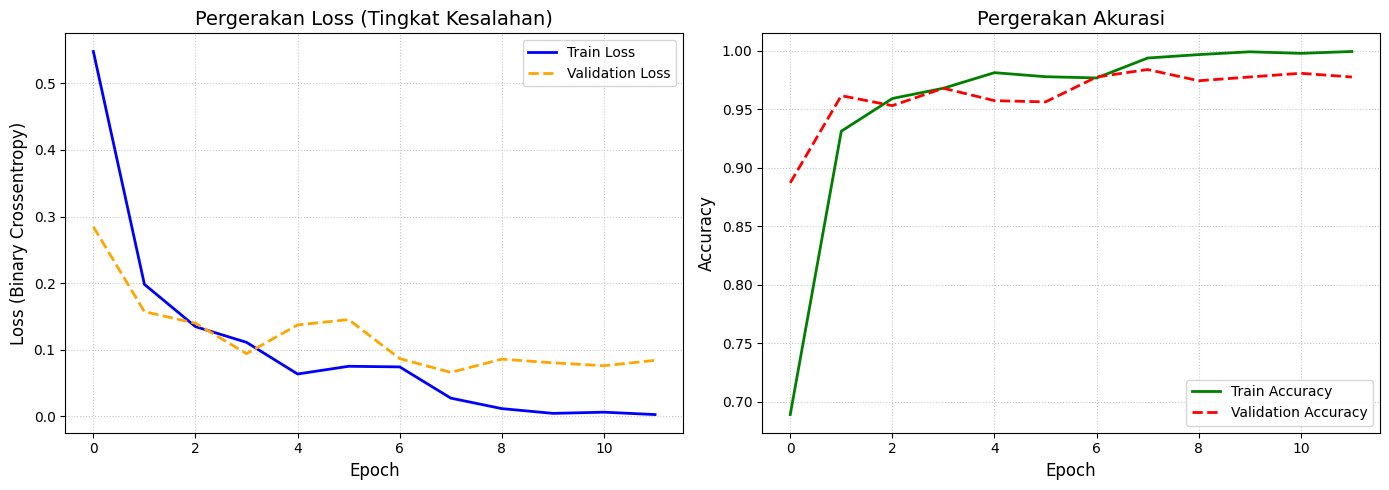

In [56]:
import matplotlib.pyplot as plt

# Mengatur ukuran kanvas grafik
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- 1. Grafik Pergerakan Loss ---
ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--')
ax1.set_title('Pergerakan Loss (Tingkat Kesalahan)', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (Binary Crossentropy)', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.7)

# --- 2. Grafik Pergerakan Akurasi ---
ax2.plot(history.history['accuracy'], label='Train Accuracy', color='green', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2, linestyle='--')
ax2.set_title('Pergerakan Akurasi', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(loc='lower right')
ax2.grid(True, linestyle=':', alpha=0.7)

# Menampilkan grafik
plt.tight_layout()
plt.show()

Sedang melakukan prediksi pada data testing...
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 235ms/step

          CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Tidak Cocok (0)       1.00      0.96      0.98       406
      Cocok (1)       0.96      1.00      0.98       423

       accuracy                           0.98       829
      macro avg       0.98      0.98      0.98       829
   weighted avg       0.98      0.98      0.98       829



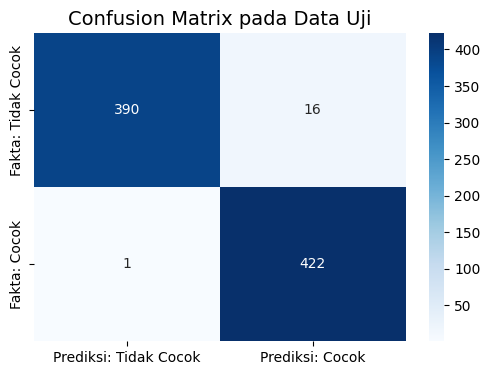

In [57]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lakukan prediksi menggunakan data testing
print("Sedang melakukan prediksi pada data testing...")
y_pred_prob = model.predict([X_cv_core_test, X_cv_ctx_test, X_job_core_test, X_job_ctx_test])

# 2. Ubah probabilitas menjadi label kelas (0 atau 1) dengan threshold 0.5
# Jika probabilitas > 0.5, maka True (1), jika tidak maka False (0)
y_pred_classes = (y_pred_prob > 0.5).astype(int).flatten()

# 3. Tampilkan Classification Report
print("\n" + "="*40)
print("          CLASSIFICATION REPORT")
print("="*40)
print(classification_report(y_test, y_pred_classes, target_names=['Tidak Cocok (0)', 'Cocok (1)']))

# 4. (Opsional) Tampilkan Confusion Matrix agar lebih visual
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi: Tidak Cocok', 'Prediksi: Cocok'],
            yticklabels=['Fakta: Tidak Cocok', 'Fakta: Cocok'])
plt.title('Confusion Matrix pada Data Uji', fontsize=14)
plt.show()

In [16]:
# Menghitung kemiripan (Dot Product sering dipakai untuk mengukur similarity di neural network)
# similarity = Dot(axes=1, normalize=True, name="cosine_similarity")([cv_vector, job_vector])

# # Gabungkan menjadi satu model
# model = Model(inputs=[cv_input, job_input], outputs=similarity)

# model.compile(optimizer='adam', loss='mse', metrics=['mae'])
# model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cv_input            │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ job_input           │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_embedding    │ (None, 150, 64)   │    640,000 │ cv_input[0][0],   │
│ (Embedding)         │                   │            │ job_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_bilstm       │ (None, 128)       │     66,048 │ shared_embedding… │
│ (Bidirectional)     │                   │            │ shared_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cosine_similarity   │ (None, 1)         │          0 │ shared_bilstm[0]… │
│ (Dot)               │                   │            │ shared_bilstm[1]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 706,048 (2.69 MB)

 Trainable params: 706,048 (2.69 MB)

 Non-trainable params: 0 (0.00 B)

Total data Train (termasuk Validation nanti): 4693
Total data Test murni: 829


In [21]:
# 4. TRAINING MODEL
# Karena target kita asal jalan dulu, 5-10 epoch sudah cukup
# model.fit(
#     x=[X_cv_train, X_job_train],
#     y=labels,
#     epochs=5,
#     batch_size=32,
#     validation_split=0.2
# )

Epoch 1/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.2230 - mae: 0.3574 - val_loss: 0.5234 - val_mae: 0.7184
Epoch 2/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.1973 - mae: 0.3793 - val_loss: 0.6029 - val_mae: 0.7749
Epoch 3/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1920 - mae: 0.3782 - val_loss: 0.6284 - val_mae: 0.7903
Epoch 4/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1843 - mae: 0.3668 - val_loss: 0.6002 - val_mae: 0.7694
Epoch 5/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.1702 - mae: 0.3410 - val_loss: 0.5065 - val_mae: 0.6994


In [59]:
import pickle

# Tentukan path penyimpanan di Google Drive kamu
# Menggunakan folder yang sama dengan tempat dataset kamu berada

# save_path = '/content/drive/MyDrive/Dataset_codingcamp_loker/'
save_path = './model_hasil/'

# 1. Menyimpan Model Keras
# Menggunakan format .keras yang merupakan standar terbaru dan terefisien dari TensorFlow
model.save(save_path + 'model_rekomendasi_2.keras')

# 2. Menyimpan Tokenizer menggunakan Pickle
with open(save_path + 'tokenizer_loker2.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# print("Model dan Tokenizer berhasil disimpan dengan aman di Google Drive!")

In [22]:
# print("\n=== Evaluasi pada Data Test Murni ===")
# eval_results = model.evaluate(x=[X_cv_test, X_job_test], y=y_test)

# print(f"Loss pada Data Test: {eval_results[0]:.4f}")
# print(f"MAE pada Data Test: {eval_results[1]:.4f}")


=== Evaluasi pada Data Test Murni ===
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2913 - mae: 0.4802
Loss pada Data Test: 0.2913
MAE pada Data Test: 0.4802


In [63]:
# df['cv_core'] = (
#     "judul: " + df['Judul'].fillna('') + " " + 
#     "skills: " + df['Skills'].fillna('')
# )
# df['cv_context'] = (
#     "industri: " + df['Industri'].fillna('') + " " +
#     "pendidikan: " + df['Pendidikan'].fillna('')
# )

# menampilkan contoh data test
print("\n=== Contoh Data Test ===")

print(f"CV: {cv_core[0][:300]}...")  # Menampilkan 50 token pertama dari CV
print(f"Context CV: {cv_ctx[0][:300]}...")


=== Contoh Data Test ===
CV: skills: sql business analysis relational databases system analysis analytical skills sdlc...
Context CV: industri: information technology and services kategori: system analyst pendidikan: bachelor degree...


In [67]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Teks CV dari User (Bisa didapat dari input form)
text_cv_core = "skills: Python, Machine Learning, SQL, Deep Learning, Data Visualization"
text_cv_ctx = "industri: Teknologi kategori: data engineer pendidikan: S1 bachelor"

# 2. Siapkan semua teks lowongan kerja dari database (menggunakan text_gabungan)
text_job_core = df['job_core'].tolist()
text_job_ctx = df['job_context'].tolist()
jumlah_lowongan = len(text_job_core)

# 3. Gandakan teks CV user agar jumlahnya sama dengan jumlah lowongan
# Ini menciptakan pasangan (CV User, Job 1), (CV User, Job 2), dst...
teks_cv_core_digandakan = [text_cv_core] * jumlah_lowongan
teks_cv_ctx_digandakan = [text_cv_ctx] * jumlah_lowongan

# 4. Tokenisasi dan Padding
seq_cv_core_infer = pad_sequences(tokenizer.texts_to_sequences(teks_cv_core_digandakan), maxlen=MAX_LEN_CORE, padding='post')
seq_cv_ctx_infer = pad_sequences(tokenizer.texts_to_sequences(teks_cv_ctx_digandakan), maxlen=MAX_LEN_CTX, padding='post')
seq_job_core_infer = pad_sequences(tokenizer.texts_to_sequences(text_job_core), maxlen=MAX_LEN_CORE, padding='post')
seq_job_ctx_infer = pad_sequences(tokenizer.texts_to_sequences(text_job_ctx), maxlen=MAX_LEN_CTX, padding='post')

print("1. Menghitung skor kecocokan dari model Deep Learning...")
skor_lstm = model.predict([seq_cv_core_infer, seq_cv_ctx_infer, seq_job_core_infer, seq_job_ctx_infer])
skor_lstm = skor_lstm.flatten()

print("2. Menghitung skor kemiripan kata kunci Judul (TF-IDF)...")
tfidf = TfidfVectorizer(ngram_range=(1, 2)) 

# Gabungkan seluruh judul dari dataframe + judul dari CV user di baris terakhir
# Kita hanya mengambil teks aslinya (misal dari df['Judul']) agar pencocokan katanya bersih
daftar_judul = df['Judul'].fillna('').tolist() + ["Data Scientist"]  # Tambahkan judul dari CV user di akhir daftar
tfidf_matrix = tfidf.fit_transform(daftar_judul)

# Hitung similarity antara baris terakhir (CV User) dengan seluruh baris lowongan sebelumnya
skor_tfidf_judul = cosine_similarity(tfidf_matrix[-1], tfidf_matrix[:-1]).flatten()

skor_akhir = (0.5 * skor_lstm) + (0.5 * skor_tfidf_judul)


# 6. Mengurutkan hasil dari skor tertinggi ke terendah
# argsort mengembalikan index. '[::-1]' digunakan untuk membalik urutan agar yang terbesar di awal.
index_terbaik = np.argsort(skor_akhir)[::-1]

# 7. Tampilkan Top 5 Rekomendasi Teratas
top_n = 30
print(f"\n=== TOP {top_n} REKOMENDASI LOWONGAN KERJA ===")

for i in range(top_n):
    idx = index_terbaik[i]
    skor = skor_akhir[idx]

    # Hanya tampilkan jika skornya di atas threshold (misal > 0.5)
    if skor > 0.45:
        print(f"\nRekomendasi #{i+1} (Skor Kecocokan: {skor:.4f})")
        # Mengambil data dari raw dataframe berdasarkan index
        print(f"Judul    : {df.loc[idx, 'Judul']}")
        print(f"Perusahaan: {df.loc[idx, 'Industri']}") # Ganti dengan kolom yang sesuai
        print(f"Lokasi   : {df.loc[idx, 'Kota']}")
    else:
        print(f"\nRekomendasi #{i+1}: Tidak ada lagi lowongan yang dianggap cocok (Skor < 0.5)")
        break

1. Menghitung skor kecocokan dari model Deep Learning...
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step
2. Menghitung skor kemiripan kata kunci Judul (TF-IDF)...

=== TOP 30 REKOMENDASI LOWONGAN KERJA ===

Rekomendasi #1 (Skor Kecocokan: 0.5289)
Judul    : Data Scienstist
Perusahaan: Information Technology and Services
Lokasi   : Jakarta Selatan

Rekomendasi #2 (Skor Kecocokan: 0.5065)
Judul    : Data Validator Staff
Perusahaan: Marketing and Advertising
Lokasi   : Jakarta Selatan

Rekomendasi #3 (Skor Kecocokan: 0.5000)
Judul    : Data Scientist
Perusahaan: Human Resources
Lokasi   : Jakarta Pusat

Rekomendasi #4 (Skor Kecocokan: 0.5000)
Judul    : Data Scientist
Perusahaan: Outsourcing/Offshoring
Lokasi   : Jakarta Selatan

Rekomendasi #5 (Skor Kecocokan: 0.4982)
Judul    : Graphic Designer
Perusahaan: Marketing and Advertising
Lokasi   : Jakarta Timur

Rekomendasi #6 (Skor Kecocokan: 0.4982)
Judul    : Finance, Accounting & Tax Supervisor
Perusahaan: Consumer Goods
Lokasi   : Bekasi

Rekom